# Use Case — Portfolio Heat Evaluation for the Real-Estate Agent

**Who this is for**  
Real-estate agents preparing a portfolio review with a client; portfolio managers and client advisors; secondarily REIT asset managers, private real-estate investors, and property operations leads.

**The scenario**  
You manage (or advise on) a 10-asset San Jose portfolio. The client wants to know which assets are at heat risk *today*, which represent the biggest *opportunity* if you treat them, and what those answers mean in dollars. Walking a building per day is not an option — you need a desk-first screening that gives you defensible numbers and slide-ready visuals before the meeting.

This notebook combines **your portfolio data** with **FortyGuard layers** to answer five questions:

1. **Where in the portfolio is hot, when, and by how much?**  ← 24-hour heatmap × portfolio
2. **Why are the hottest properties hot?**  ← satellite segmentation on top exposures
3. **What does the curb actually look like?**  ← street-view ground-truth on the #1 exposure
4. **What does tenant comfort look like through the day?**  ← environmental parameters
5. **What's the risk and the opportunity per asset, in dollars and tiers?**  ← composite scoring + business translation

> **Cached by default.** The notebook ships with `CACHED=True` so it runs end-to-end against the bundled sample files in `data/` — no API key needed for the demo. Set `CACHED=False` at the top of the Setup cell to run the same workflow live against any portfolio.

> **Bring your own portfolio.** Sample data ships at `data/real_estate_san_jose_portfolio_sample.csv`. Swap the path in Step 1 — as long as the columns match (`property_id`, `name`, `type`, `year_built`, `sqft`, `market_value_musd`, `latitude`, `longitude`), everything downstream works.

---

## Setup

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / '.env')

import json
import random
import pandas as pd
import folium
import matplotlib.pyplot as plt
from shapely.geometry import Point, shape, mapping
from IPython.display import HTML, display

from fortyguard import FortyGuardClient
from fortyguard.samples import SAN_JOSE_POLYGON

# ── configuration ─────────────────────────────────────
STUDY_DATE         = '2024-10-02'         # matches the bundled cached files
STUDY_HOUR         = '14:00'              # design-peak snapshot for the live API
GRANULARITY_M      = 100                  # heatmap resolution
TOP_N_TO_ENRICH    = 3                    # API budget for satellite / env-params
CACHED             = True                 # set False for live API calls
BASELINE_C         = 24.0                 # comfortable ambient baseline
COOLING_KWH_PER_SF = 0.18                 # extra kWh per sf per °C above baseline
KWH_PRICE_USD      = 0.24
SLA_HI_C           = 32.0                 # tenant-comfort heat-index threshold
TEMP_C_SANITY      = (15.0, 55.0)         # F→C conversion sanity range
ASSET_TYPE_PALETTE = {
    'Office':       '#1f77b4',
    'Residential':  '#2ca02c',
    'Retail':       '#ff7f0e',
    'Mixed-Use':    '#9467bd',
    'Industrial':   '#8c564b',
}

# ── data paths ─────────────────────────────────────────
DATA            = ROOT / 'data'
PORTFOLIO_CSV   = DATA / 'real_estate_san_jose_portfolio_sample.csv'
HEATMAP_GEOJSON = DATA / 'real_state_san_jose_heatmap_sample_day_2024-10-02.geojson'
SATELLITE_JSON  = DATA / 'real_state_san_jose_satellite_segmentation_sample_day_2024-10-02.json'
STREETVIEW_JSON = DATA / 'real_state_san_jose_street_view_segmentation_sample_day_2024-10-02.json'
ENV_PARAMS_JSON = DATA / 'real_state_san_jose_env_paramaters_sample_day_2024-10-02.json'
HEAT_INTEL_PDF  = DATA / 'real_state_san_jose_heat_intelligence_sample_day_2024-10-02.pdf'
OUTPUT_CSV      = ROOT / 'outputs' / 'portfolio_evaluation.csv'
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)

client = FortyGuardClient()  # used only when CACHED=False
print(f"CACHED={CACHED}  STUDY_DATE={STUDY_DATE}  TOP_N_TO_ENRICH={TOP_N_TO_ENRICH}")

CACHED=True  STUDY_DATE=2024-10-02  TOP_N_TO_ENRICH=3


---
## Step 1 — Load your portfolio

### What you are doing
Reading the portfolio CSV. Any columns may ride along — the workflow only needs `latitude` and `longitude` to do the geospatial work; the rest pass through to the final output so finance and ops see the asset IDs and values they already recognize.

### Why this matters
Starting from the operations system of record means the output carries *your* property IDs, *your* asset types, *your* square-footages — ready to paste into the client report or CRM.

In [2]:
portfolio = pd.read_csv(PORTFOLIO_CSV)
type_counts = portfolio['type'].value_counts().to_dict()
print(f"Loaded {len(portfolio)} properties, "
      f"total value ${portfolio['market_value_musd'].sum():.0f}M, "
      f"total {portfolio['sqft'].sum():,} sqft")
print(f"  asset-type mix: {type_counts}")
portfolio

Loaded 10 properties, total value $2155M, total 2,690,000 sqft
  asset-type mix: {'Office': 4, 'Residential': 3, 'Retail': 1, 'Mixed-Use': 1, 'Industrial': 1}


,property_id,name,type,year_built,sqft,market_value_musd,latitude,longitude
0,P01,Adobe Campus Tower,Office,2015,620000,450,37.2963,-121.8341
1,P02,Downtown Commons Residences,Residential,2019,340000,380,37.3410,-121.8890
2,P03,City View Office Plaza,Office,1987,450000,280,37.3370,-121.8905
3,P04,Santa Clara Street Retail,Retail,1952,45000,35,37.3378,-121.8870
4,P05,San Pedro Square Mixed-Use,Mixed-Use,2005,220000,195,37.3376,-121.8940
5,P06,Japantown Lofts,Residential,1920,95000,88,37.3445,-121.8945
6,P07,Paseo Office Center,Office,1998,320000,260,37.3362,-121.8895
7,P08,Southside Industrial,Industrial,1965,180000,62,37.3315,-121.8920
8,P09,The Fairmont Residences,Residential,2010,140000,225,37.3328,-121.8870
9,P10,Tech Corridor Offices,Office,1989,280000,180,37.3392,-121.8810


---
## Step 2 — Heat layer (online or cached)

### What you are doing
When `CACHED=True` we read the bundled 24-hour heatmap GeoJSON — 16,507 tiles, each carrying hourly temperatures `'00'..'23'` plus min/max/avg. Values in the file are in °F, so we convert and assert a sanity range. When `CACHED=False` we call `client.create_heatmap` for the design hour.

### Why this matters
A city-wide weather observation misses intra-city variation that *actually* drives cooling cost and tenant complaints. At 100 m resolution we can distinguish a building on the hot side of a block from one on the cool side. The 24-hour cached layer also unlocks **peak-hour** and **diurnal-swing** signals you cannot get from a single-hour call.

In [3]:
def _f_to_c(f):
    return (f - 32.0) * 5.0 / 9.0

def _load_cached_heatmap():
    """Return (tiles, aoi_bounds). tiles = list of (polygon, hourly_c, peak_c, peak_h, min_c)."""
    with open(HEATMAP_GEOJSON, 'r', encoding='utf-8') as f:
        gj = json.load(f)
    feats = gj.get('features', [])
    tiles = []
    minx = miny =  1e9
    maxx = maxy = -1e9
    for ft in feats:
        poly = shape(ft['geometry'])
        props = ft['properties']
        hourly_c = [_f_to_c(props[f"{h:02d}"]) for h in range(24)]
        peak_c   = max(hourly_c)
        peak_h   = hourly_c.index(peak_c)
        min_c    = min(hourly_c)
        tiles.append((poly, hourly_c, peak_c, peak_h, min_c))
        x0, y0, x1, y1 = poly.bounds
        if x0 < minx: minx = x0
        if y0 < miny: miny = y0
        if x1 > maxx: maxx = x1
        if y1 > maxy: maxy = y1
    return tiles, (minx, miny, maxx, maxy)

if CACHED:
    tiles, aoi_bounds = _load_cached_heatmap()
    peaks = [t[2] for t in tiles]
    lo, hi = min(peaks), max(peaks)
    assert TEMP_C_SANITY[0] <= lo and hi <= TEMP_C_SANITY[1], \
        f"F→C sanity check failed: peak range {lo:.1f}..{hi:.1f} outside {TEMP_C_SANITY}"
    print(f"[cached] {len(tiles)} tiles, peak temp range {lo:.1f}..{hi:.1f} °C")
    print(f"[cached] AOI bounds (lon,lat): ({aoi_bounds[0]:.4f}, {aoi_bounds[1]:.4f}) → "
          f"({aoi_bounds[2]:.4f}, {aoi_bounds[3]:.4f})")
else:
    heatmap = client.create_heatmap(
        polygon_aoi=SAN_JOSE_POLYGON, start_date=STUDY_DATE, start_time=STUDY_HOUR,
        filter_type=1, granularity=GRANULARITY_M,
    )
    map_data = heatmap['result'].get('map_data') or {}
    feats = map_data.get('features', []) if isinstance(map_data, dict) else []
    tiles = []
    minx = miny =  1e9
    maxx = maxy = -1e9
    sh = int(STUDY_HOUR.split(':')[0])
    for ft in feats:
        poly = shape(ft['geometry'])
        t = ft['properties'].get('temperature')
        # Single-hour live data: broadcast to 24-hour tuple so downstream code is uniform.
        # Diurnal columns will be degenerate in this mode — see banner below.
        hourly_c = [t] * 24
        tiles.append((poly, hourly_c, t, sh, t))
        x0, y0, x1, y1 = poly.bounds
        if x0 < minx: minx = x0
        if y0 < miny: miny = y0
        if x1 > maxx: maxx = x1
        if y1 > maxy: maxy = y1
    aoi_bounds = (minx, miny, maxx, maxy)
    print(f"[online] {len(tiles)} tiles at {GRANULARITY_M}m, single hour {STUDY_HOUR}.")
    print("[online] ⚠ Diurnal swing / peak_hour / aoi_percentile collapse to the snapshot "
          "hour. Use CACHED=True with a 24h GeoJSON for full-day analysis.")

def tile_for(lat, lon):
    p = Point(lon, lat)
    for t in tiles:
        if t[0].contains(p):
            return t
    return min(tiles, key=lambda t: t[0].centroid.distance(p))

[cached] 16507 tiles, peak temp range 37.2..40.7 °C
[cached] AOI bounds (lon,lat): (-121.9430, 37.2930) → (-121.8280, 37.3850)


---
## Step 3 — Diurnal temperature attach

### What you are doing
For each property, find the tile that contains it, copy off the **peak temperature**, **peak hour**, **min temperature**, **diurnal swing**, and the **AOI percentile** (this property's peak relative to all 16,507 city tiles). Now every property has an analysis-ready row.

### Why this matters
This is the moment your portfolio table becomes a *risk* table. Every downstream question — ranking, scoring, business translation — is a `groupby` or sort on this DataFrame.

In [4]:
def _percentile_rank(value, sorted_values):
    lo, hi = 0, len(sorted_values)
    while lo < hi:
        mid = (lo + hi) // 2
        if sorted_values[mid] <= value: lo = mid + 1
        else: hi = mid
    return round(100.0 * lo / max(1, len(sorted_values)), 1)

aoi_peak_sorted = sorted(t[2] for t in tiles)

records = []
for _, r in portfolio.iterrows():
    poly, hourly_c, peak_c, peak_h, min_c = tile_for(r.latitude, r.longitude)
    records.append({
        'peak_temp_c'   : round(peak_c, 1),
        'peak_hour'     : peak_h,
        'min_temp_c'    : round(min_c, 1),
        'diurnal_swing_c': round(peak_c - min_c, 1),
        'aoi_percentile': _percentile_rank(peak_c, aoi_peak_sorted),
    })
portfolio = pd.concat([portfolio.reset_index(drop=True), pd.DataFrame(records)], axis=1)
portfolio = portfolio.sort_values('peak_temp_c', ascending=False).reset_index(drop=True)
portfolio.insert(0, 'temp_rank', portfolio.index + 1)

cols_t1 = ['temp_rank', 'property_id', 'name', 'type', 'sqft',
           'peak_temp_c', 'peak_hour', 'min_temp_c', 'diurnal_swing_c', 'aoi_percentile']
portfolio[cols_t1]

,temp_rank,property_id,name,type,sqft,peak_temp_c,peak_hour,min_temp_c,diurnal_swing_c,aoi_percentile
0,1,P01,Adobe Campus Tower,Office,620000,40.7,15,18.7,22.1,99.5
1,2,P08,Southside Industrial,Industrial,180000,40.5,15,19.3,21.2,76.6
2,3,P09,The Fairmont Residences,Residential,140000,40.1,15,19.3,20.8,58.1
3,4,P07,Paseo Office Center,Office,320000,40.1,15,19.3,20.8,58.1
4,5,P02,Downtown Commons Residences,Residential,340000,39.8,16,19.3,20.5,42.3
5,6,P03,City View Office Plaza,Office,450000,39.8,16,19.3,20.5,42.3
6,7,P06,Japantown Lofts,Residential,95000,39.8,16,19.3,20.5,36.2
7,8,P05,San Pedro Square Mixed-Use,Mixed-Use,220000,39.8,16,19.3,20.5,37.3
8,9,P04,Santa Clara Street Retail,Retail,45000,39.8,16,19.3,20.5,42.3
9,10,P10,Tech Corridor Offices,Office,280000,39.8,16,19.2,20.6,43.5


---
## Step 4 — Portfolio overview map (M1)

### What you are doing
Rendering every property on a folium map. Marker size scales with peak temperature; color encodes asset type. Popups show the dollar value, square footage, peak temperature, peak hour, and AOI percentile.

### Why this matters
This is the slide-1 visual for the client meeting. Before any score is computed, the map already tells the agent which assets to talk about — the big red circles.

In [5]:
def _legend_html(palette):
    rows = ''.join(
        f'<tr><td style="background:{c};width:18px;"></td>'
        f'<td style="padding-left:6px;">{name}</td></tr>'
        for name, c in palette.items()
    )
    return (
        '<div style="position:fixed;bottom:30px;left:30px;z-index:9999;'
        'background:white;padding:8px 12px;border:1px solid #888;'
        'font:12px sans-serif;">'
        '<b>Asset type</b>'
        f'<table>{rows}</table>'
        '</div>'
    )

center = [portfolio['latitude'].mean(), portfolio['longitude'].mean()]
m1 = folium.Map(location=center, zoom_start=13, tiles='cartodbpositron')

min_peak = portfolio['peak_temp_c'].min()
for _, p in portfolio.iterrows():
    folium.CircleMarker(
        location=[p.latitude, p.longitude],
        radius=4 + (p.peak_temp_c - min_peak) * 1.2,
        color='#333', weight=1,
        fill=True, fill_color=ASSET_TYPE_PALETTE.get(p['type'], '#888'),
        fill_opacity=0.85,
        popup=(f"<b>{p['name']}</b><br/>"
               f"{p['type']}, {p['sqft']:,} sqft, ${p['market_value_musd']}M<br/>"
               f"peak: {p.peak_temp_c:.1f}°C @ {int(p.peak_hour):02d}:00<br/>"
               f"AOI percentile: {p.aoi_percentile}"),
    ).add_to(m1)

m1.get_root().html.add_child(folium.Element(_legend_html(ASSET_TYPE_PALETTE)))
m1

---
## Step 5 — Above-average hot exposures (M2)

### What you are doing
Filtering to properties whose peak temperature is at or above the portfolio median, and overlaying the city's hottest-tile network (AOI 90th percentile) underneath. The zoomed map M2 shows where the action is.

### Why this matters
The agent doesn't need ten talking points; they need three. M2 is the slide-2 visual that says: "these are the assets we have to discuss."

In [6]:
median_peak = portfolio['peak_temp_c'].median()
hot = portfolio[portfolio['peak_temp_c'] >= median_peak].copy()

p90 = sorted(t[2] for t in tiles)[int(0.90 * len(tiles))]
overlay_tiles = [t for t in tiles if t[2] >= p90]
if len(overlay_tiles) > 500:
    random.seed(42)
    overlay_tiles = random.sample(overlay_tiles, 500)

m2 = folium.Map(location=center, zoom_start=14, tiles='cartodbpositron')
for poly, _, peak_c, _, _ in overlay_tiles:
    folium.GeoJson(
        mapping(poly),
        style_function=lambda x: {
            'fillColor': '#d73027', 'color': '#d73027',
            'weight': 0, 'fillOpacity': 0.25,
        },
    ).add_to(m2)
for _, p in hot.iterrows():
    folium.CircleMarker(
        location=[p.latitude, p.longitude],
        radius=8, color='black', weight=1,
        fill=True, fill_color=ASSET_TYPE_PALETTE.get(p['type'], '#888'), fill_opacity=0.9,
        popup=(f"#{p.temp_rank} {p['name']}<br/>"
               f"peak: {p.peak_temp_c:.1f}°C @ {int(p.peak_hour):02d}:00"),
    ).add_to(m2)

print(f"{len(hot)} above-average exposures (median peak {median_peak:.1f}°C); "
      f"city 90th-pct = {p90:.1f}°C ({len(overlay_tiles)} tiles shown)")
display(m2)
hot[['temp_rank','property_id','name','type','peak_temp_c','peak_hour','aoi_percentile']]

10 above-average exposures (median peak 39.8°C); city 90th-pct = 40.6°C (500 tiles shown)


,temp_rank,property_id,name,type,peak_temp_c,peak_hour,aoi_percentile
0,1,P01,Adobe Campus Tower,Office,40.7,15,99.5
1,2,P08,Southside Industrial,Industrial,40.5,15,76.6
2,3,P09,The Fairmont Residences,Residential,40.1,15,58.1
3,4,P07,Paseo Office Center,Office,40.1,15,58.1
4,5,P02,Downtown Commons Residences,Residential,39.8,16,42.3
5,6,P03,City View Office Plaza,Office,39.8,16,42.3
6,7,P06,Japantown Lofts,Residential,39.8,16,36.2
7,8,P05,San Pedro Square Mixed-Use,Mixed-Use,39.8,16,37.3
8,9,P04,Santa Clara Street Retail,Retail,39.8,16,42.3
9,10,P10,Tech Corridor Offices,Office,39.8,16,43.5


---
## Step 6 — Surface diagnosis (satellite segmentation)

### What you are doing
For the top-N hottest properties, characterize the surface mix in their immediate surroundings: building, road, sidewalk, tree, grass. We bucket those into `impervious_pct` and `vegetation_pct` for scoring, and chart the full breakdown.

### Why this matters
Temperature alone doesn't tell you what to spend money on. A hot property surrounded by impervious rooftops is a cool-roof candidate. A hot property with minimal vegetation is a planting candidate. The surface mix points to the lever — without us prescribing which one to pull.

⚠ Cached deep-dive applies to ['P01'] only. Set CACHED=False to enrich the full top-3.


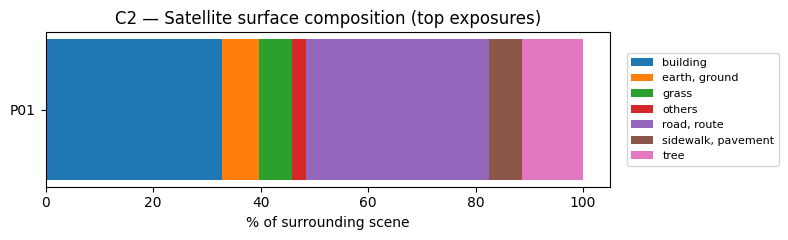

,temp_rank,property_id,name,peak_temp_c,impervious_pct,vegetation_pct
0,1,P01,Adobe Campus Tower,40.7,79.9,17.4
1,2,P08,Southside Industrial,40.5,NaN,NaN
2,3,P09,The Fairmont Residences,40.1,NaN,NaN


In [7]:
IMPERV_KEYS = {'road', 'roads', 'pavement', 'building', 'buildings',
               'rooftop', 'rooftops', 'sidewalk', 'earth', 'bare', 'ground'}
VEGGIE_KEYS = {'vegetation', 'tree', 'trees', 'grass', 'greenery', 'park'}

def _bucket(segments, keys):
    total = 0.0
    for cls, pct in (segments or {}).items():
        if any(k in cls.lower() for k in keys):
            try: total += float(pct)
            except (TypeError, ValueError): pass
    return round(total, 1)

top_n = portfolio.head(TOP_N_TO_ENRICH).copy()
seg_data = {}  # property_id -> segments dict

if CACHED:
    with open(SATELLITE_JSON, 'r', encoding='utf-8') as f:
        sat_doc = json.load(f)
    sat_lat = float(sat_doc['coordinates']['latitude'])
    sat_lon = float(sat_doc['coordinates']['longitude'])
    sat_segs = sat_doc['segmentation'].get('segments', {}) or {}
    matches = portfolio[
        (portfolio['latitude'].sub(sat_lat).abs() < 1e-3) &
        (portfolio['longitude'].sub(sat_lon).abs() < 1e-3)
    ]
    if len(matches):
        pid = matches.iloc[0]['property_id']
        seg_data[pid] = sat_segs
        if pid not in top_n['property_id'].values:
            top_n = pd.concat([top_n, portfolio[portfolio['property_id'] == pid]],
                              ignore_index=True)
    print(f"⚠ Cached deep-dive applies to {list(seg_data.keys())} only. "
          f"Set CACHED=False to enrich the full top-{TOP_N_TO_ENRICH}.")
else:
    for _, r in top_n.iterrows():
        print(f"  satellite: #{int(r.temp_rank)} {r.property_id}")
        sat = client.satellite_segmentation(
            latitude=r.latitude, longitude=r.longitude,
            start_date=STUDY_DATE, start_time=STUDY_HOUR,
            filter_type=1, granularity=GRANULARITY_M, verbose=False,
        )
        seg_data[r.property_id] = sat['result'].get('segmentation', {}).get('segments', {}) or {}

top_n['impervious_pct'] = top_n['property_id'].map(
    lambda pid: _bucket(seg_data.get(pid), IMPERV_KEYS) if pid in seg_data else None)
top_n['vegetation_pct'] = top_n['property_id'].map(
    lambda pid: _bucket(seg_data.get(pid), VEGGIE_KEYS) if pid in seg_data else None)

enriched_rows = [(pid, segs) for pid, segs in seg_data.items() if segs]
if enriched_rows:
    classes = sorted({c for _, s in enriched_rows for c in s.keys()})
    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.8 * len(enriched_rows))))
    bottoms = [0.0] * len(enriched_rows)
    pids    = [pid for pid, _ in enriched_rows]
    for c in classes:
        vals = [float(segs.get(c, 0.0)) for _, segs in enriched_rows]
        ax.barh(pids, vals, left=bottoms, label=c)
        bottoms = [b + v for b, v in zip(bottoms, vals)]
    ax.set_xlabel('% of surrounding scene')
    ax.set_title('C2 — Satellite surface composition (top exposures)')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    plt.tight_layout(); plt.show()

top_n[['temp_rank','property_id','name','peak_temp_c','impervious_pct','vegetation_pct']]

---
## Step 7 — Street-view ground truth on #1

### What you are doing
Pulling the front-facing street view at the highest-ranked enriched property and rendering the original alongside the segmented version. Tabulating the front-view composition (sky, building, tree, road, sidewalk, car, grass).

### Why this matters
Satellite shows the roof; the agent's client walks past the curb. Sky-fraction tells you canyon openness; car-fraction tells you traffic load; tree-fraction at the curb is what a passer-by experiences. This step grounds the satellite story in something a non-engineer recognizes.

Street-view #1 = P01 (Adobe Campus Tower) — imagery date 2022-10-01 (front view only)



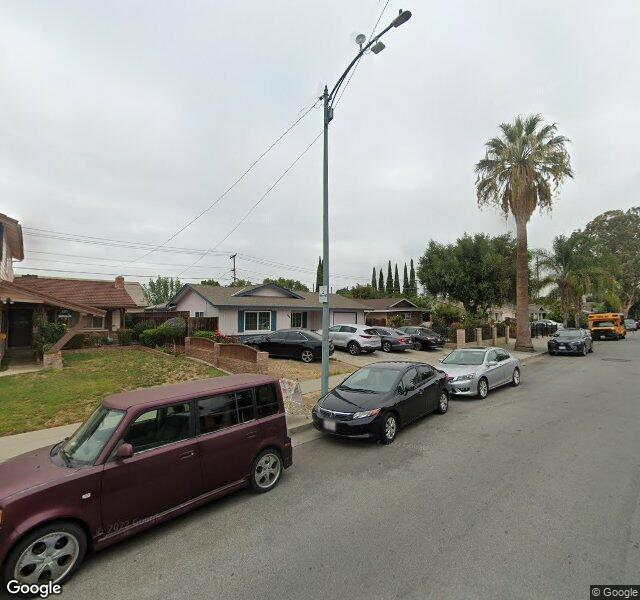
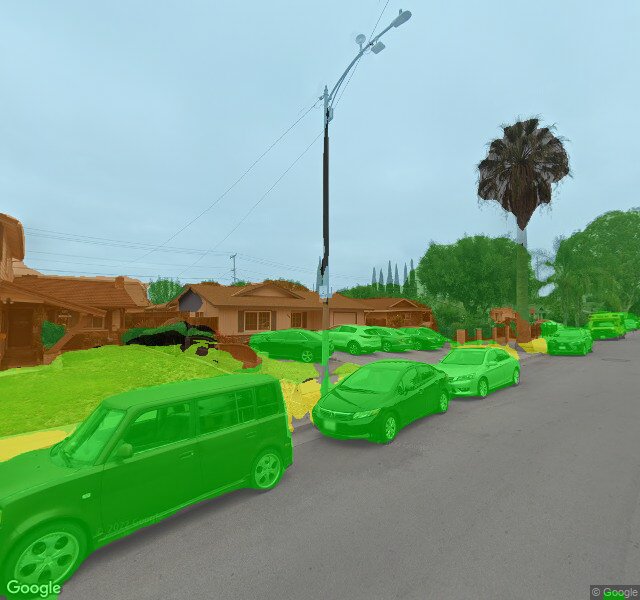

,class,pct
0,sky,42.30
1,road,24.18
2,car,15.07
3,building,6.48
4,tree,5.46
5,grass,3.49
6,others,2.25
7,sidewalk,0.77


In [8]:
# "Property #1" = highest temp_rank within the enriched subset
enriched_subset = top_n[top_n['property_id'].isin(seg_data.keys())] if seg_data else top_n
property_one = enriched_subset.iloc[0] if len(enriched_subset) else top_n.iloc[0]

if CACHED:
    with open(STREETVIEW_JSON, 'r', encoding='utf-8') as f:
        sv = json.load(f)
    front      = sv.get('front', {}) or {}
    sv_orig    = front.get('original_image')
    sv_seg     = front.get('segmented_image')
    sv_segs    = front.get('segments', {}) or {}
    image_date = front.get('image_date', 'n/a')
else:
    sv_resp = client.street_view_segmentation(
        latitude=property_one.latitude, longitude=property_one.longitude,
        start_date=STUDY_DATE, start_time=STUDY_HOUR,
        filter_type=1, granularity=GRANULARITY_M, verbose=False,
    )
    front      = (sv_resp['result'] or {}).get('front', {}) or {}
    sv_orig    = front.get('original_image')
    sv_seg     = front.get('segmented_image')
    sv_segs    = front.get('segments', {}) or {}
    image_date = front.get('image_date', 'n/a')

print(f"Street-view #1 = {property_one['property_id']} ({property_one['name']}) — "
      f"imagery date {image_date} (front view only)")

def _img_tag(b64, label):
    if not b64:
        return f'<div style="padding:1em;border:1px dashed #888;width:350px">{label}: missing</div>'
    return (f'<figure style="margin:0">'
            f'<img src="data:image/jpeg;base64,{b64}" '
            f'style="width:350px;border:1px solid #888;"/>'
            f'<figcaption style="text-align:center;font:11px sans-serif">{label}</figcaption>'
            f'</figure>')

display(HTML(
    '<div style="display:flex;gap:12px;flex-wrap:wrap">'
    + _img_tag(sv_orig, 'original') + _img_tag(sv_seg, 'segmented') +
    '</div>'
))

pd.DataFrame(sorted(sv_segs.items(), key=lambda kv: -kv[1]),
             columns=['class', 'pct'])

---
## Step 8 — Diurnal driver profile (env-params)

### What you are doing
Pulling the full-day environmental parameters for the top-N exposures: heat index, apparent temperature, relative humidity, solar irradiance. Computing per property: peak heat index, peak apparent temperature, hours-above-SLA in business hours (09:00–18:00), peak solar irradiance.

### Why this matters
Tenant-comfort SLAs are written in terms of heat index, not dry-bulb temperature. A building at 34 °C ambient with low humidity is comfortable; one at 31 °C with 80 % humidity is not. Heat index is the number complaints cluster around — and it's what the leasing team will quote back to you.

⚠ Cached env-params apply to ['P01'] only. Set CACHED=False to enrich the full top-3.


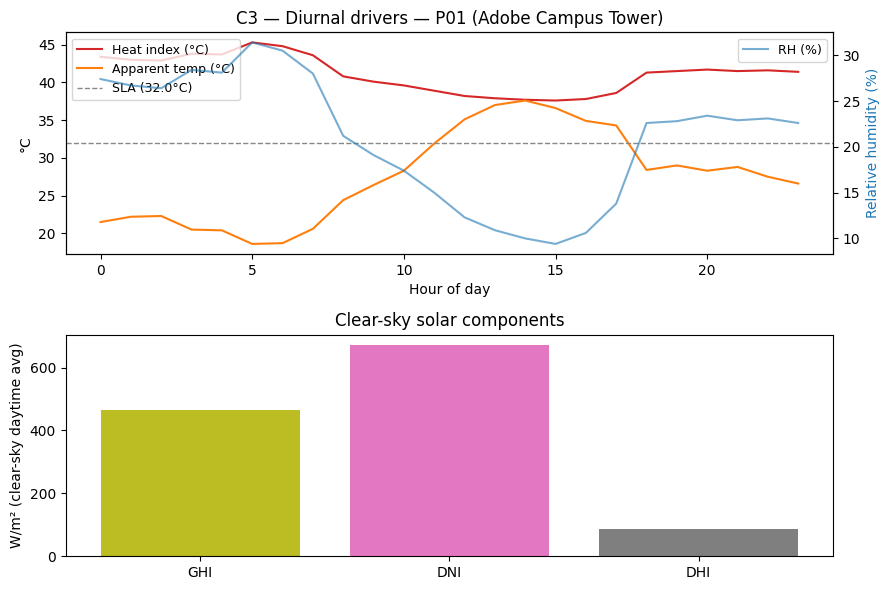

,temp_rank,property_id,name,peak_temp_c,peak_heat_index_c,peak_apparent_temp_c,hours_above_sla
0,1,P01,Adobe Campus Tower,40.7,45.3,37.6,10.0
1,2,P08,Southside Industrial,40.5,NaN,NaN,NaN
2,3,P09,The Fairmont Residences,40.1,NaN,NaN,NaN


In [9]:
def _slice_business_hours(values):
    return [values[h] for h in range(9, 19)]  # 09:00..18:00 inclusive

env_data = {}  # property_id -> dict of full-day series

if CACHED:
    with open(ENV_PARAMS_JSON, 'r', encoding='utf-8') as f:
        env_doc = json.load(f)
    loc = env_doc['locations'][0]
    env_lat, env_lon = float(loc['lat']), float(loc['lon'])
    params = loc.get('parameters', {}) or {}
    series = {
        'heat_index_celsius'           : list(params.get('heat_index_celsius') or []),
        'apparent_temperature_celsius' : list(params.get('apparent_temperature_celsius') or []),
        'relative_humidity_percent'    : list(params.get('relative_humidity_percent') or []),
        # Solar may be a 24-hour series OR a daytime-aggregate dict (clear_sky.ghi/dni/dhi).
        'solar_irradiance'             : loc.get('solar_irradiance'),
    }
    matches = portfolio[
        (portfolio['latitude'].sub(env_lat).abs() < 1e-3) &
        (portfolio['longitude'].sub(env_lon).abs() < 1e-3)
    ]
    if len(matches):
        env_data[matches.iloc[0]['property_id']] = series
    print(f"⚠ Cached env-params apply to {list(env_data.keys())} only. "
          f"Set CACHED=False to enrich the full top-{TOP_N_TO_ENRICH}.")
else:
    for _, r in top_n.iterrows():
        print(f"  env-params: #{int(r.temp_rank)} {r.property_id}")
        env = client.environmental_parameters(
            latitude=r.latitude, longitude=r.longitude,
            temperature=float(r.peak_temp_c),
            start_date=STUDY_DATE, start_time='09:00', end_time='18:00',
            filter_type=2, verbose=False,
        )
        loc = env['result']['locations'][0]
        p = loc.get('parameters', {}) or {}
        env_data[r.property_id] = {
            'heat_index_celsius'           : list(p.get('heat_index_celsius') or []),
            'apparent_temperature_celsius' : list(p.get('apparent_temperature_celsius') or []),
            'relative_humidity_percent'    : list(p.get('relative_humidity_percent') or []),
            'solar_irradiance'             : loc.get('solar_irradiance'),
        }

def _peak_solar(sol_raw):
    if isinstance(sol_raw, list) and sol_raw:
        return max(sol_raw)
    if isinstance(sol_raw, dict):
        return (sol_raw.get('clear_sky') or {}).get('ghi')
    return None

def _peak_metrics(s):
    hi   = s.get('heat_index_celsius') or []
    appt = s.get('apparent_temperature_celsius') or []
    business = _slice_business_hours(hi) if len(hi) >= 19 else hi
    return {
        'peak_heat_index_c'    : max(hi) if hi else None,
        'peak_apparent_temp_c' : max(appt) if appt else None,
        'hours_above_sla'      : sum(1 for v in business if v is not None and v > SLA_HI_C),
        'peak_solar_irradiance': _peak_solar(s.get('solar_irradiance')),
    }

metrics = {pid: _peak_metrics(s) for pid, s in env_data.items()}
for col in ('peak_heat_index_c', 'peak_apparent_temp_c', 'hours_above_sla', 'peak_solar_irradiance'):
    top_n[col] = top_n['property_id'].map(lambda p, _c=col: (metrics.get(p) or {}).get(_c))

if property_one['property_id'] in env_data:
    s = env_data[property_one['property_id']]
    n = len(s.get('heat_index_celsius') or [])
    hours = list(range(n))
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 6))
    if s.get('heat_index_celsius'):
        ax_top.plot(hours, s['heat_index_celsius'], label='Heat index (°C)', color='#d62728')
    if s.get('apparent_temperature_celsius'):
        ax_top.plot(hours, s['apparent_temperature_celsius'], label='Apparent temp (°C)', color='#ff7f0e')
    ax_top.axhline(SLA_HI_C, color='#888', linestyle='--', linewidth=1, label=f'SLA ({SLA_HI_C}°C)')
    ax_top.set_ylabel('°C')
    ax_top.set_xlabel('Hour of day')
    ax_top.legend(loc='upper left', fontsize=9)
    if s.get('relative_humidity_percent'):
        ax_rh = ax_top.twinx()
        ax_rh.plot(hours, s['relative_humidity_percent'], label='RH (%)', color='#1f77b4', alpha=0.6)
        ax_rh.set_ylabel('Relative humidity (%)', color='#1f77b4')
        ax_rh.legend(loc='upper right', fontsize=9)

    sol_raw = s.get('solar_irradiance')
    if isinstance(sol_raw, list) and sol_raw:
        ax_bot.plot(range(len(sol_raw)), sol_raw, color='#bcbd22')
        ax_bot.set_xlabel('Hour of day')
        ax_bot.set_ylabel('Solar irradiance (W/m²)')
    elif isinstance(sol_raw, dict) and sol_raw.get('clear_sky'):
        cs = sol_raw['clear_sky']
        ax_bot.bar(['GHI', 'DNI', 'DHI'],
                   [cs.get('ghi', 0), cs.get('dni', 0), cs.get('dhi', 0)],
                   color=['#bcbd22', '#e377c2', '#7f7f7f'])
        ax_bot.set_ylabel('W/m² (clear-sky daytime avg)')
        ax_bot.set_title('Clear-sky solar components')
    else:
        ax_bot.text(0.5, 0.5, 'No solar irradiance data', transform=ax_bot.transAxes,
                    ha='center', va='center', color='#888')
        ax_bot.set_xticks([]); ax_bot.set_yticks([])

    ax_top.set_title(f"C3 — Diurnal drivers — {property_one['property_id']} ({property_one['name']})")
    plt.tight_layout(); plt.show()

top_n[['temp_rank','property_id','name','peak_temp_c',
       'peak_heat_index_c','peak_apparent_temp_c','hours_above_sla']]

---
## Step 9 — Composite scores (risk + opportunity)

### What you are doing
Two scores, both 0–1, both min-max-normalized on the analyzed subset:

- **`heat_risk_score`** = `0.40·peak_temp + 0.20·impervious + 0.20·peak_HI + 0.20·hours_above_SLA` — *which assets are exposed today.*
- **`opportunity_score`** = `0.50·peak_temp + 0.30·impervious + 0.20·veg_deficit` — *which assets have the most headroom for cooling investment.*

### Why this matters
The investment committee wants one number per asset for risk *and* one for upside. Two scores answer two different questions: which to flag, and which to treat. The agent uses them together — high risk + high opportunity = treat now; high risk + low opportunity = divest; low risk + high opportunity = hold and watch.

In [10]:
def _mm(s):
    s = pd.Series(s).astype(float)
    lo, hi = s.min(skipna=True), s.max(skipna=True)
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return s * 0.0
    return (s - lo) / (hi - lo)

analyzed = top_n.dropna(subset=['impervious_pct', 'vegetation_pct',
                                 'peak_heat_index_c', 'hours_above_sla']).copy()
if len(analyzed) < 2:
    print(f"⚠ Analyzed subset has {len(analyzed)} property — scores are not comparable "
          f"across assets in this run. Set CACHED=False or expand cached coverage "
          f"to score the full top-{TOP_N_TO_ENRICH}.")

temp_n  = _mm(analyzed['peak_temp_c'])
imp_n   = _mm(analyzed['impervious_pct'])
hi_n    = _mm(analyzed['peak_heat_index_c'])
sla_n   = _mm(analyzed['hours_above_sla'])
veg_def = _mm(100.0 - analyzed['vegetation_pct'])

analyzed['heat_risk_score']   = (0.40*temp_n + 0.20*imp_n + 0.20*hi_n + 0.20*sla_n).round(3)
analyzed['opportunity_score'] = (0.50*temp_n + 0.30*imp_n + 0.20*veg_def).round(3)

top_n = top_n.merge(
    analyzed[['property_id','heat_risk_score','opportunity_score']],
    on='property_id', how='left',
)

top_n[['temp_rank','property_id','name','peak_temp_c',
       'impervious_pct','vegetation_pct','peak_heat_index_c','hours_above_sla',
       'heat_risk_score','opportunity_score']]

⚠ Analyzed subset has 1 property — scores are not comparable across assets in this run. Set CACHED=False or expand cached coverage to score the full top-3.


,temp_rank,property_id,name,peak_temp_c,impervious_pct,vegetation_pct,peak_heat_index_c,hours_above_sla,heat_risk_score,opportunity_score
0,1,P01,Adobe Campus Tower,40.7,79.9,17.4,45.3,10.0,0.0,0.0
1,2,P08,Southside Industrial,40.5,NaN,NaN,NaN,NaN,NaN,NaN
2,3,P09,The Fairmont Residences,40.1,NaN,NaN,NaN,NaN,NaN,NaN


---
## Step 10 — Business translation + investment summary

### What you are doing
Translating the technical numbers into the four outputs the agent's client actually cares about:

- **Cooling OpEx uplift (USD / yr)** — `(Δ°C above 24) × sqft × 0.18 kWh/sf/°C × $0.24/kWh`. Triage-grade, defensible at a meeting.
- **Insurance risk tier** A / B / C — percentile buckets on `heat_risk_score`.
- **Tenant-comfort SLA flag** — boolean, flips when peak heat index is above 32 °C.
- **Final ranked map M3 + risk-vs-opportunity scatter C4 + diurnal curves C1.**

### Why this matters
“Property X has a heat-risk score of 0.82” is a modeling statement. “Property X is in tier C, carries ~$58 k/yr in avoidable cooling OpEx, and will breach the comfort SLA on design-peak days” is a decision.

In [11]:
def _opex_uplift(peak_temp_c, sqft):
    if pd.isna(peak_temp_c): return None
    delta = max(0.0, peak_temp_c - BASELINE_C)
    return round(delta * sqft * COOLING_KWH_PER_SF * KWH_PRICE_USD, 0)

def _tier(score):
    if pd.isna(score): return 'unranked'
    if score >= 0.67:  return 'C'
    if score >= 0.33:  return 'B'
    return 'A'

def _comfort_flag(hi):
    if pd.isna(hi): return None
    return bool(hi > SLA_HI_C)

portfolio = portfolio.merge(
    top_n[['property_id','impervious_pct','vegetation_pct',
           'peak_heat_index_c','peak_apparent_temp_c','hours_above_sla',
           'peak_solar_irradiance','heat_risk_score','opportunity_score']],
    on='property_id', how='left',
)
portfolio['cooling_opex_uplift_usd'] = portfolio.apply(
    lambda r: _opex_uplift(r.peak_temp_c, r.sqft), axis=1)
portfolio['insurance_tier']   = portfolio['heat_risk_score'].apply(_tier)
portfolio['comfort_sla_risk'] = portfolio['peak_heat_index_c'].apply(_comfort_flag)

out_cols = [
    'temp_rank','property_id','name','type','sqft','market_value_musd',
    'peak_temp_c','peak_hour','diurnal_swing_c','aoi_percentile',
    'impervious_pct','vegetation_pct','peak_heat_index_c','hours_above_sla',
    'heat_risk_score','opportunity_score',
    'cooling_opex_uplift_usd','insurance_tier','comfort_sla_risk',
]
portfolio[out_cols].to_csv(OUTPUT_CSV, index=False)
print(f"Saved → {OUTPUT_CSV}")
print(f"Aggregate avoidable cooling OpEx: $"
      f"{portfolio['cooling_opex_uplift_usd'].sum():,.0f} / year")
portfolio[out_cols]

Saved → C:\development\fortyguard\repositories\temperature-api-quickstart\outputs\portfolio_evaluation.csv
Aggregate avoidable cooling OpEx: $1,871,596 / year


,temp_rank,property_id,name,type,sqft,market_value_musd,peak_temp_c,peak_hour,diurnal_swing_c,aoi_percentile,impervious_pct,vegetation_pct,peak_heat_index_c,hours_above_sla,heat_risk_score,opportunity_score,cooling_opex_uplift_usd,insurance_tier,comfort_sla_risk
0,1,P01,Adobe Campus Tower,Office,620000,450,40.7,15,22.1,99.5,79.9,17.4,45.3,10.0,0.0,0.0,447293.0,A,True
1,2,P08,Southside Industrial,Industrial,180000,62,40.5,15,21.2,76.6,NaN,NaN,NaN,NaN,NaN,NaN,128304.0,unranked,None
2,3,P09,The Fairmont Residences,Residential,140000,225,40.1,15,20.8,58.1,NaN,NaN,NaN,NaN,NaN,NaN,97373.0,unranked,None
3,4,P07,Paseo Office Center,Office,320000,260,40.1,15,20.8,58.1,NaN,NaN,NaN,NaN,NaN,NaN,222566.0,unranked,None
4,5,P02,Downtown Commons Residences,Residential,340000,380,39.8,16,20.5,42.3,NaN,NaN,NaN,NaN,NaN,NaN,232070.0,unranked,None
5,6,P03,City View Office Plaza,Office,450000,280,39.8,16,20.5,42.3,NaN,NaN,NaN,NaN,NaN,NaN,307152.0,unranked,None
6,7,P06,Japantown Lofts,Residential,95000,88,39.8,16,20.5,36.2,NaN,NaN,NaN,NaN,NaN,NaN,64843.0,unranked,None
7,8,P05,San Pedro Square Mixed-Use,Mixed-Use,220000,195,39.8,16,20.5,37.3,NaN,NaN,NaN,NaN,NaN,NaN,150163.0,unranked,None
8,9,P04,Santa Clara Street Retail,Retail,45000,35,39.8,16,20.5,42.3,NaN,NaN,NaN,NaN,NaN,NaN,30715.0,unranked,None
9,10,P10,Tech Corridor Offices,Office,280000,180,39.8,16,20.6,43.5,NaN,NaN,NaN,NaN,NaN,NaN,191117.0,unranked,None


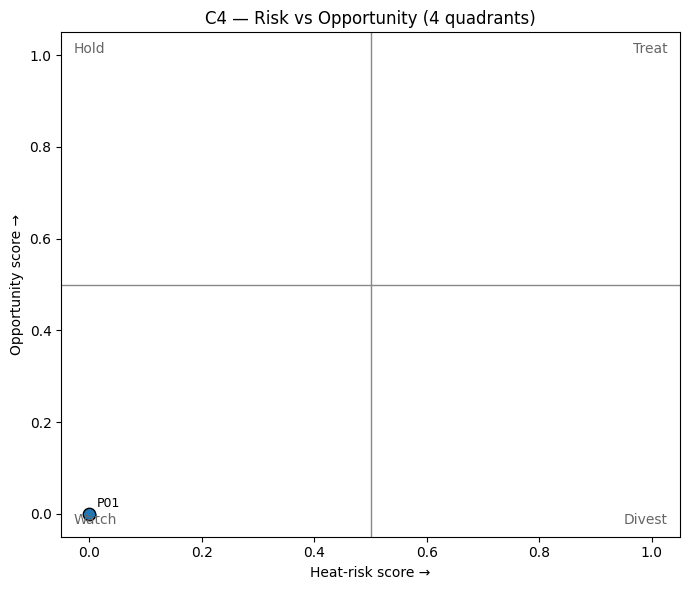

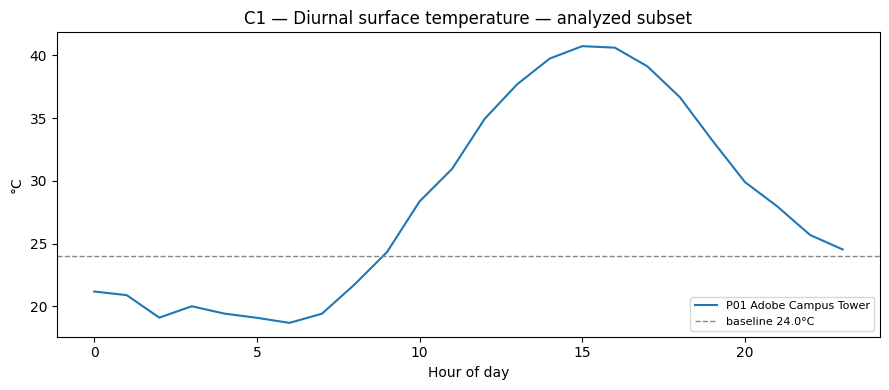

In [12]:
# Map M3 — final ranked priority map
m3 = folium.Map(location=center, zoom_start=14, tiles='cartodbpositron')
for poly, _, peak_c, _, _ in overlay_tiles:
    folium.GeoJson(
        mapping(poly),
        style_function=lambda x: {
            'fillColor': '#d73027', 'color': '#d73027',
            'weight': 0, 'fillOpacity': 0.20,
        },
    ).add_to(m3)
for _, p in portfolio.iterrows():
    score = p.heat_risk_score if pd.notna(p.heat_risk_score) else 0.0
    color = '#d73027' if score >= 0.67 else ('#fee090' if score >= 0.33 else '#1a9850')
    folium.CircleMarker(
        location=[p.latitude, p.longitude],
        radius=6 + score * 14,
        color='black', weight=1,
        fill=True, fill_color=color, fill_opacity=0.9,
        popup=(f"<b>#{int(p.temp_rank)} {p['name']}</b><br/>"
               f"risk: {p.heat_risk_score if pd.notna(p.heat_risk_score) else 'n/a'}<br/>"
               f"opportunity: {p.opportunity_score if pd.notna(p.opportunity_score) else 'n/a'}<br/>"
               f"OpEx uplift: ${(p.cooling_opex_uplift_usd or 0):,.0f}/yr<br/>"
               f"tier: {p.insurance_tier}, SLA risk: {p.comfort_sla_risk}"),
    ).add_to(m3)
display(m3)

# Chart C4 — Risk vs Opportunity scatter (4 quadrants for the agent)
scored = portfolio.dropna(subset=['heat_risk_score', 'opportunity_score'])
if len(scored):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(scored['heat_risk_score'], scored['opportunity_score'],
               s=80, c='#1f77b4', edgecolor='black')
    for _, r in scored.iterrows():
        ax.annotate(r['property_id'], (r['heat_risk_score'], r['opportunity_score']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax.axvline(0.5, color='#888', linewidth=1)
    ax.axhline(0.5, color='#888', linewidth=1)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Heat-risk score →')
    ax.set_ylabel('Opportunity score →')
    ax.set_title('C4 — Risk vs Opportunity (4 quadrants)')
    ax.text(0.02, 0.98, 'Hold',   transform=ax.transAxes, fontsize=10, color='#666', va='top')
    ax.text(0.98, 0.98, 'Treat',  transform=ax.transAxes, fontsize=10, color='#666', va='top', ha='right')
    ax.text(0.02, 0.02, 'Watch',  transform=ax.transAxes, fontsize=10, color='#666', va='bottom')
    ax.text(0.98, 0.02, 'Divest', transform=ax.transAxes, fontsize=10, color='#666', va='bottom', ha='right')
    plt.tight_layout(); plt.show()

# Chart C1 — Diurnal temperature curves for the analyzed subset
analyzed_pids = list(env_data.keys()) or list(top_n['property_id'].head(TOP_N_TO_ENRICH))
fig, ax = plt.subplots(figsize=(9, 4))
for _, p in portfolio[portfolio['property_id'].isin(analyzed_pids)].iterrows():
    poly, hourly_c, peak_c, peak_h, min_c = tile_for(p.latitude, p.longitude)
    ax.plot(range(24), hourly_c, label=f"{p['property_id']} {p['name']}")
ax.axhline(BASELINE_C, color='#888', linestyle='--', linewidth=1, label=f'baseline {BASELINE_C}°C')
ax.set_xlabel('Hour of day'); ax.set_ylabel('°C')
ax.set_title('C1 — Diurnal surface temperature — analyzed subset')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

---
## Wrap-up

Starting from a real-estate portfolio CSV you now have evidence-based answers for the client meeting:

| Artifact | Used by |
|----------|---------|
| **M1** portfolio overview map | Client deck — slide 1 |
| **M2** hot-exposures zoom map | Client deck — slide 2 |
| **M3** final ranked priority map | Client deck — slide 3 |
| **C1** diurnal temperature curves | Backup / analyst review |
| **C2** surface composition stacked bar | Backup |
| **C3** HI / apparent / RH / solar profile (#1) | Deep-dive slide |
| **C4** risk vs opportunity scatter (4 quadrants) | Decision slide |
| `outputs/portfolio_evaluation.csv` | CRM / client report |
| [Heat-intelligence PDF report](../../data/real_state_san_jose_heat_intelligence_sample_day_2024-10-02.pdf) | Forward to client unchanged |

Every input is explicit. Every weight is at the top of the notebook. Set `CACHED=False` to rerun against any portfolio with a live FortyGuard API key — the same workflow applies, with the caveat that diurnal columns reduce to the snapshot hour until a 24-hour live API is available.

**Apply this pattern to adjacent use cases**: insured-properties portfolio (insurance underwriting), data-center sites (operational-risk screening), hospitality assets (guest-comfort benchmarking), retail acquisitions (foot-traffic comfort). The workflow — *portfolio × diurnal heatmap × surface diagnosis × ground-truth × env-params → risk + opportunity table* — transfers directly.